In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Moaz\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [2]:

df = pd.read_csv("final_dataset.csv")

In [3]:

X = df[['Weight', 'Height', 'Gender', 'Age']]
y = df['Exercise Recommendation Plan']


le_gender = LabelEncoder()
X_encoded = X.copy()
X_encoded['Gender'] = le_gender.fit_transform(X['Gender'])

In [4]:

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.30, random_state=42)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:


model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(8, activation='softmax') 
])

Building the model...


In [6]:

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                320       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 32)                2080      
                                                                 
 dense_3 (Dense)             (None, 8)                 264       
                                                                 
Total params: 6,824
Trainable params: 6,824
Non-trainabl

In [7]:

print("Training the model...")
history = model.fit(X_train_scaled, y_train, 
                   epochs=100, 
                   validation_split=0.2,
                   batch_size=32,
                   verbose=1)

Training the model...
Epoch 1/100
88/88 [==============================] - 1s 3ms/step - loss: 1.5912 - accuracy: 0.4461 - val_loss: 1.0806 - val_accuracy: 0.7100
Epoch 2/100
88/88 [==============================] - 0s 1ms/step - loss: 1.0197 - accuracy: 0.6114 - val_loss: 0.7397 - val_accuracy: 0.7843
Epoch 3/100
88/88 [==============================] - 0s 2ms/step - loss: 0.8374 - accuracy: 0.6657 - val_loss: 0.6235 - val_accuracy: 0.8043
Epoch 4/100
88/88 [==============================] - 0s 1ms/step - loss: 0.7505 - accuracy: 0.6804 - val_loss: 0.5578 - val_accuracy: 0.8043
Epoch 5/100
88/88 [==============================] - 0s 2ms/step - loss: 0.7064 - accuracy: 0.7093 - val_loss: 0.5285 - val_accuracy: 0.8229
Epoch 6/100
88/88 [==============================] - 0s 1ms/step - loss: 0.6876 - accuracy: 0.7104 - val_loss: 0.5028 - val_accuracy: 0.8314
Epoch 7/100
88/88 [==============================] - 0s 2ms/step - loss: 0.6401 - accuracy: 0.7282 - val_loss: 0.4949 - val_accuracy

In [8]:


test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}')


Test Loss: 0.2854, Test Accuracy: 0.8740


In [9]:

y_pred_proba = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_proba, axis=1)

In [10]:

def predict_exercise_plan(weight, height, gender, age):
    """
    Predict exercise recommendation plan for given parameters
    
    Parameters:
    weight (float): Weight in kg
    height (float): Height in cm
    gender (str): 'Male' or 'Female'
    age (int): Age in years
    
    Returns:
    tuple: (predicted_class, confidence_scores)
    """
    
    gender_encoded = le_gender.transform([gender])[0]
    input_data = np.array([[weight, height, gender_encoded, age]])
    
    
    input_scaled = scaler.transform(input_data)
    
    prediction_proba = model.predict(input_scaled, verbose=0)
    predicted_class = np.argmax(prediction_proba, axis=1)[0]
    confidence = np.max(prediction_proba)
    
    return predicted_class, prediction_proba[0], confidence

In [24]:

print("\n" + "="*50)
print("EVALUATION METRICS")
print("="*50)

from sklearn.metrics import (precision_score, recall_score, f1_score, 
                           roc_auc_score, matthews_corrcoef, 
                           balanced_accuracy_score, cohen_kappa_score)


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced Accuracy: {balanced_acc:.4f}")


precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
precision_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
recall_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"\nPrecision (Macro): {precision_macro:.4f}")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"Recall (Weighted): {recall_weighted:.4f}")
print(f"F1-Score (Macro): {f1_macro:.4f}")
print(f"F1-Score (Weighted): {f1_weighted:.4f}")


precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

print(f"\nPer-Class Metrics:")
exercise_plans = [f'Plan_{i}' for i in range(8)]  
for i, plan in enumerate(exercise_plans):
    if i < len(precision_per_class):
        print(f"{plan}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")





try:
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Matthews Correlation Coefficient: {mcc:.4f}")
except Exception as e:
    print(f"MCC could not be calculated: {str(e)}")





print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)


print("\nPer-Class Accuracy:")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, plan in enumerate(exercise_plans):
    if i < len(class_accuracy):
        print(f"{plan}: {class_accuracy[i]:.4f}")


EVALUATION METRICS
Accuracy: 0.8740
Balanced Accuracy: 0.8329

Precision (Macro): 0.8606
Precision (Weighted): 0.8742
Recall (Macro): 0.8329
Recall (Weighted): 0.8740
F1-Score (Macro): 0.8288
F1-Score (Weighted): 0.8678

Per-Class Metrics:
Plan_0: Precision=0.8214, Recall=1.0000, F1=0.9020
Plan_1: Precision=1.0000, Recall=0.4655, F1=0.6353
Plan_2: Precision=0.7816, Recall=0.9855, F1=0.8718
Plan_3: Precision=0.9842, Recall=0.9932, F1=0.9887
Plan_4: Precision=0.8789, Recall=0.9891, F1=0.9308
Plan_5: Precision=0.8174, Recall=0.7520, F1=0.7833
Plan_6: Precision=0.7407, Recall=0.6452, F1=0.6897
Matthews Correlation Coefficient: 0.8419

Confusion Matrix:
[[ 69   0   0   0   0   0   0]
 [ 15  27  16   0   0   0   0]
 [  0   0  68   1   0   0   0]
 [  0   0   3 436   0   0   0]
 [  0   0   0   2 363   1   1]
 [  0   0   0   0   7 188  55]
 [  0   0   0   4  43  41 160]]

Per-Class Accuracy:
Plan_0: 1.0000
Plan_1: 0.4655
Plan_2: 0.9855
Plan_3: 0.9932
Plan_4: 0.9891
Plan_5: 0.7520
Plan_6: 0.645

In [12]:

print(f"\n" + "="*30)
print("SUMMARY STATISTICS")
print("="*30)
print(f"Total Test Samples: {len(y_test)}")
print(f"Number of Classes: {len(np.unique(y_test))}")
print(f"Correctly Classified: {np.sum(y_test == y_pred)}")
print(f"Misclassified: {np.sum(y_test != y_pred)}")
print(f"Error Rate: {(1 - accuracy):.4f}")


print(f"\nClass Distribution in Test Set:")
unique, counts = np.unique(y_test, return_counts=True)
for class_label, count in zip(unique, counts):
    percentage = (count / len(y_test)) * 100
    print(f"Plan_{class_label}: {count} samples ({percentage:.2f}%)")


SUMMARY STATISTICS
Total Test Samples: 1500
Number of Classes: 7
Correctly Classified: 1311
Misclassified: 189
Error Rate: 0.1260

Class Distribution in Test Set:
Plan_1: 69 samples (4.60%)
Plan_2: 58 samples (3.87%)
Plan_3: 69 samples (4.60%)
Plan_4: 439 samples (29.27%)
Plan_5: 367 samples (24.47%)
Plan_6: 250 samples (16.67%)
Plan_7: 248 samples (16.53%)


In [13]:


print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)


fig = plt.figure(figsize=(20, 15))


VISUALIZATIONS


<Figure size 2000x1500 with 0 Axes>

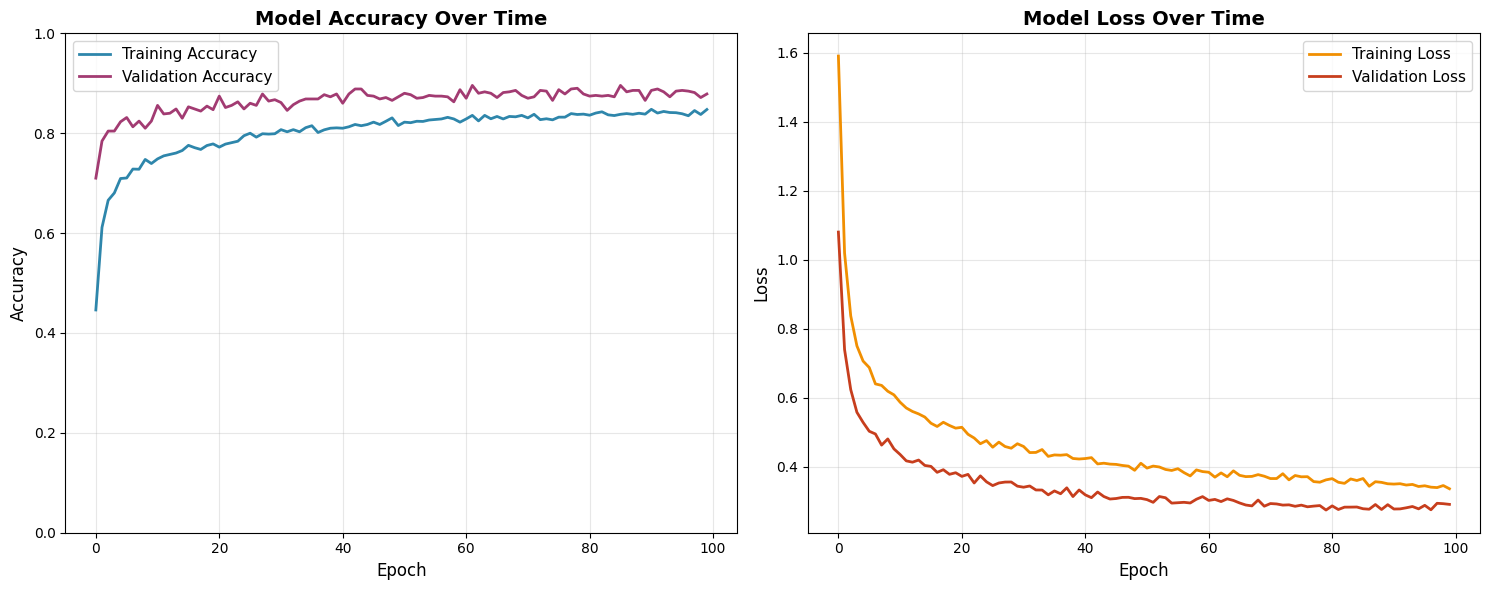

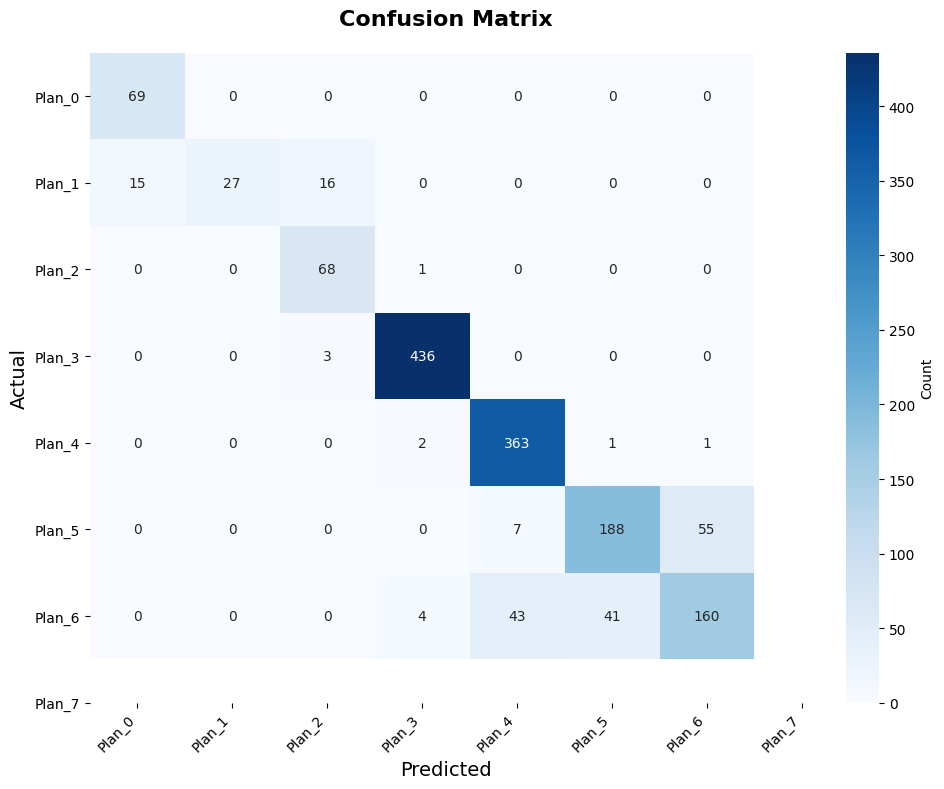

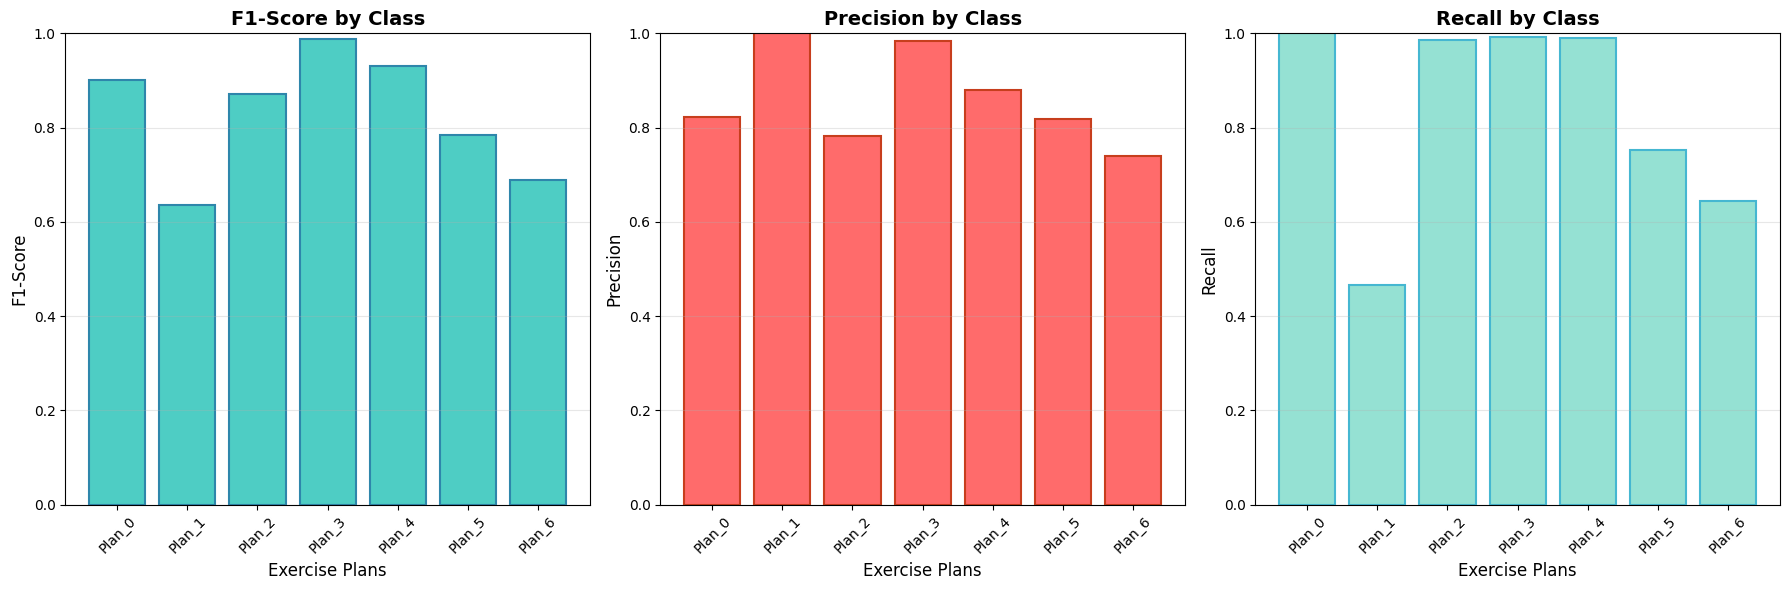

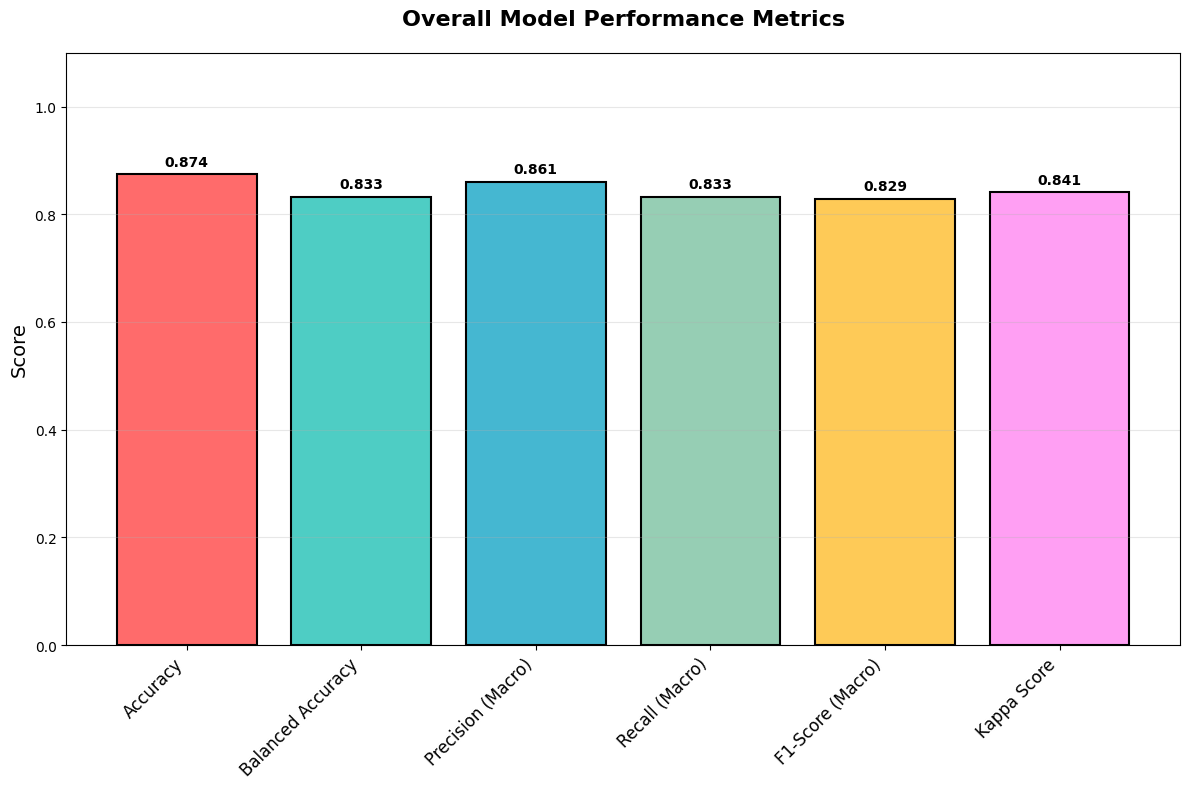

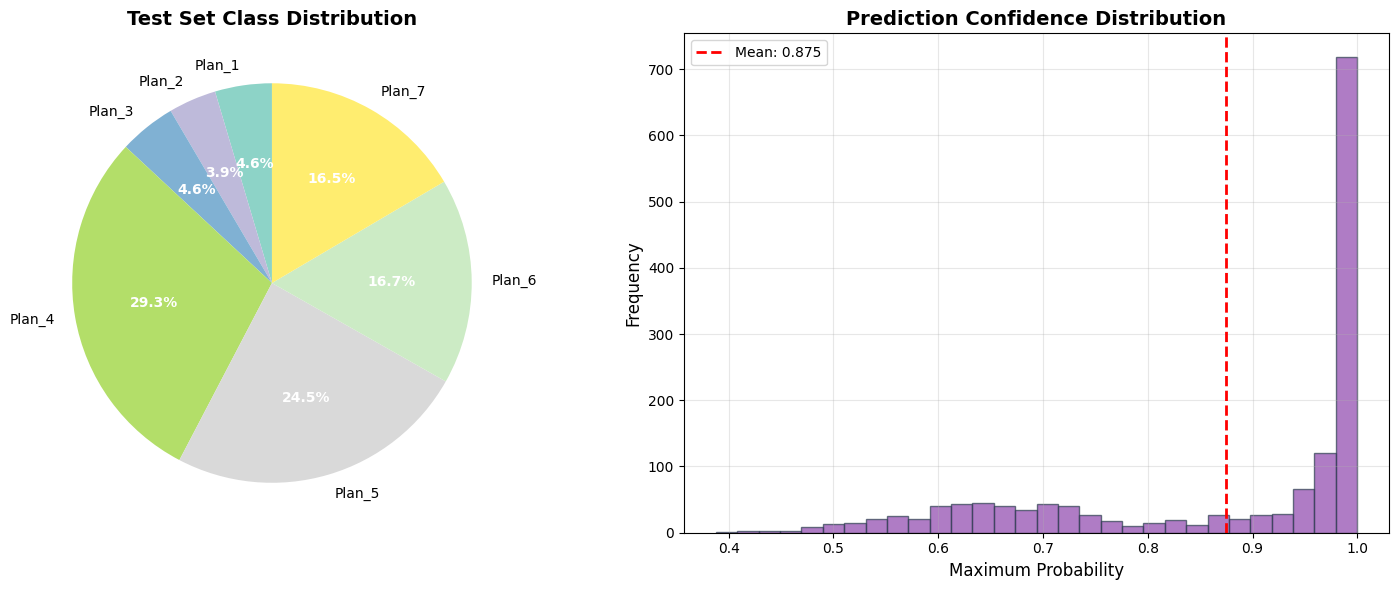


MODEL PERFORMANCE SUMMARY
Accuracy            : 0.8740
Balanced Accuracy   : 0.8329
Precision (Macro)   : 0.8606
Recall (Macro)      : 0.8329
F1-Score (Macro)    : 0.8288
Kappa Score         : 0.8407


In [23]:
# Separated Model Evaluation Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# 1. Training History (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#2E86AB')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#A23B72')
ax1.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2, color='#F18F01')
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#C73E1D')
ax2.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 2. Confusion Matrix (standalone)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=exercise_plans, yticklabels=exercise_plans,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=14)
plt.ylabel('Actual', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Per-Class Metrics (F1, Precision, Recall)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

valid_indices = range(len(f1_per_class))
x_labels = [exercise_plans[i] for i in valid_indices]

# F1-Score
ax1.bar(x_labels, [f1_per_class[i] for i in valid_indices], 
        color='#4ECDC4', edgecolor='#2E86AB', linewidth=1.5)
ax1.set_title('F1-Score by Class', fontsize=14, fontweight='bold')
ax1.set_xlabel('Exercise Plans', fontsize=12)
ax1.set_ylabel('F1-Score', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(0, 1)

# Precision
ax2.bar(x_labels, [precision_per_class[i] for i in valid_indices], 
        color='#FF6B6B', edgecolor='#C73E1D', linewidth=1.5)
ax2.set_title('Precision by Class', fontsize=14, fontweight='bold')
ax2.set_xlabel('Exercise Plans', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

# Recall
ax3.bar(x_labels, [recall_per_class[i] for i in valid_indices], 
        color='#95E1D3', edgecolor='#45B7D1', linewidth=1.5)
ax3.set_title('Recall by Class', fontsize=14, fontweight='bold')
ax3.set_xlabel('Exercise Plans', fontsize=12)
ax3.set_ylabel('Recall', fontsize=12)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# 4. Overall Metrics Comparison
plt.figure(figsize=(12, 8))
metrics_comparison = {
    'Accuracy': accuracy,
    'Balanced Accuracy': balanced_acc,
    'Precision (Macro)': precision_macro,
    'Recall (Macro)': recall_macro,
    'F1-Score (Macro)': f1_macro,
    'Kappa Score': kappa
}

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
bars = plt.bar(metrics_comparison.keys(), metrics_comparison.values(), 
               color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, value in zip(bars, metrics_comparison.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.title('Overall Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Score', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 5. Data Distribution and Confidence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Test set class distribution
unique, counts = np.unique(y_test, return_counts=True)
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(unique)))
wedges, texts, autotexts = ax1.pie(counts, labels=[f'Plan_{i}' for i in unique], 
                                   autopct='%1.1f%%', startangle=90, colors=colors_pie)
ax1.set_title('Test Set Class Distribution', fontsize=14, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Prediction confidence distribution
max_probs = np.max(y_pred_proba, axis=1)
ax2.hist(max_probs, bins=30, color='#8E44AD', alpha=0.7, edgecolor='#2C3E50', linewidth=1)
ax2.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Maximum Probability', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.axvline(np.mean(max_probs), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(max_probs):.3f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Optional: Create a summary table
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY")
print("="*60)
for metric, value in metrics_comparison.items():
    print(f"{metric:<20}: {value:.4f}")
print("="*60)

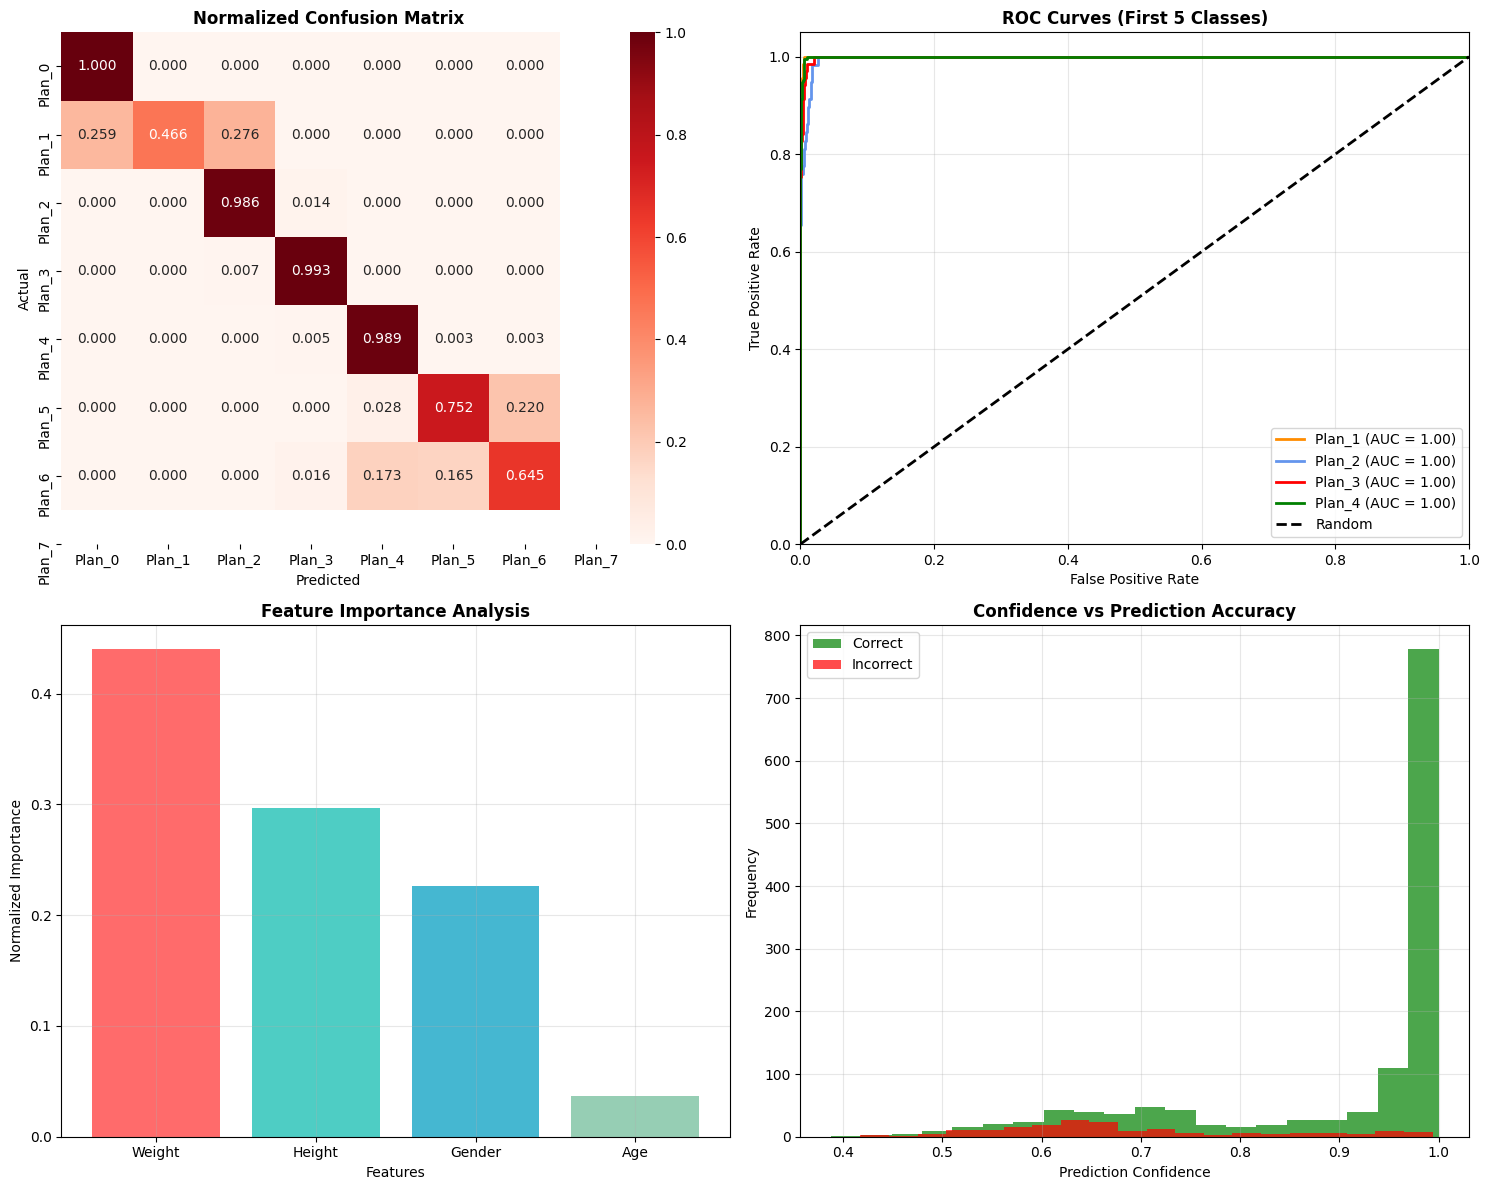

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Reds', 
            xticklabels=exercise_plans, yticklabels=exercise_plans, ax=axes[0,0])
axes[0,0].set_title('Normalized Confusion Matrix', fontweight='bold')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# ROC Curve for each class (if applicable)
try:
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    
    # Binarize the output
    y_test_bin = label_binarize(y_test, classes=range(len(exercise_plans)))
    n_classes = y_test_bin.shape[1]
    
    # Plot ROC curve for first few classes
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'red', 'green']
    for i in range(min(5, n_classes)):
        if np.sum(y_test_bin[:, i]) > 0:  
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
            roc_auc_class = auc(fpr, tpr)
            axes[0,1].plot(fpr, tpr, color=colors[i % len(colors)], lw=2,
                         label=f'{exercise_plans[i]} (AUC = {roc_auc_class:.2f})')
    
    axes[0,1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    axes[0,1].set_xlim([0.0, 1.0])
    axes[0,1].set_ylim([0.0, 1.05])
    axes[0,1].set_xlabel('False Positive Rate')
    axes[0,1].set_ylabel('True Positive Rate')
    axes[0,1].set_title('ROC Curves (First 5 Classes)', fontweight='bold')
    axes[0,1].legend(loc="lower right")
    axes[0,1].grid(True, alpha=0.3)

except Exception as e:
    axes[0,1].text(0.5, 0.5, f'ROC curves unavailable:\n{str(e)}', 
                   ha='center', va='center', transform=axes[0,1].transAxes)
    axes[0,1].set_title('ROC Curves (Unavailable)', fontweight='bold')

# Feature Importance (from first layer weights)
first_layer_weights = model.layers[0].get_weights()[0]
feature_names = ['Weight', 'Height', 'Gender', 'Age']
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
feature_importance_normalized = feature_importance / np.sum(feature_importance)

axes[1,0].bar(feature_names, feature_importance_normalized, 
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
axes[1,0].set_title('Feature Importance Analysis', fontweight='bold')
axes[1,0].set_xlabel('Features')
axes[1,0].set_ylabel('Normalized Importance')
axes[1,0].grid(True, alpha=0.3)

# Prediction Error Analysis
correct_predictions = (y_test == y_pred)
confidence_correct = max_probs[correct_predictions]
confidence_incorrect = max_probs[~correct_predictions]

axes[1,1].hist(confidence_correct, bins=20, alpha=0.7, label='Correct', color='green')
axes[1,1].hist(confidence_incorrect, bins=20, alpha=0.7, label='Incorrect', color='red')
axes[1,1].set_title('Confidence vs Prediction Accuracy', fontweight='bold')
axes[1,1].set_xlabel('Prediction Confidence')
axes[1,1].set_ylabel('Frequency')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [22]:
# Get model weights for first layer to understand feature importance
first_layer_weights = model.layers[0].get_weights()[0]
feature_names = ['Weight', 'Height', 'Gender', 'Age']

# Calculate average absolute weights for each feature
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)
feature_importance_normalized = feature_importance / np.sum(feature_importance)

print("Feature Importance:")
for i, feature in enumerate(feature_names):
    print(f"{feature}: {feature_importance_normalized[i]:.4f}")

# Create comprehensive analysis report
print(f"\n" + "="*50)
print("MODEL ANALYSIS")
print("="*50)

# Model Performance Summary
print("MODEL PERFORMANCE SUMMARY:")
print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Balanced Accuracy: {balanced_acc:.4f} ({balanced_acc*100:.2f}%)")
print(f"Macro F1-Score: {f1_macro:.4f}")
print(f"Weighted F1-Score: {f1_weighted:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Error Rate: {(1-accuracy):.4f} ({(1-accuracy)*100:.2f}%)")

# Best and Worst Performing Classes
best_f1_idx = np.argmax(f1_per_class)
worst_f1_idx = np.argmin(f1_per_class)

print(f"\nCLASS PERFORMANCE ANALYSIS:")
print(f"Best Performing Class: {exercise_plans[best_f1_idx]} (F1: {f1_per_class[best_f1_idx]:.4f})")
print(f"Worst Performing Class: {exercise_plans[worst_f1_idx]} (F1: {f1_per_class[worst_f1_idx]:.4f})")
print(f"Performance Variance: {np.var(f1_per_class):.4f}")
print(f"Average Class F1-Score: {np.mean(f1_per_class):.4f}")

# Confidence Analysis
high_confidence_threshold = 0.8
low_confidence_threshold = 0.6

high_conf_mask = max_probs >= high_confidence_threshold
low_conf_mask = max_probs < low_confidence_threshold

high_conf_accuracy = accuracy_score(y_test[high_conf_mask], y_pred[high_conf_mask]) if np.sum(high_conf_mask) > 0 else 0
low_conf_accuracy = accuracy_score(y_test[low_conf_mask], y_pred[low_conf_mask]) if np.sum(low_conf_mask) > 0 else 0

print(f"\nCONFIDENCE ANALYSIS:")
print(f"High Confidence (≥{high_confidence_threshold}) Predictions: {np.sum(high_conf_mask)} ({np.sum(high_conf_mask)/len(y_test)*100:.1f}%)")
print(f"High Confidence Accuracy: {high_conf_accuracy:.4f}")
print(f"Low Confidence (<{low_confidence_threshold}) Predictions: {np.sum(low_conf_mask)} ({np.sum(low_conf_mask)/len(y_test)*100:.1f}%)")
print(f"Low Confidence Accuracy: {low_conf_accuracy:.4f}")
print(f"Average Prediction Confidence: {np.mean(max_probs):.4f}")

# Misclassification Analysis
misclassified_mask = y_test != y_pred
if np.sum(misclassified_mask) > 0:
    misclassified_confidence = max_probs[misclassified_mask]
    print(f"\nMISCLASSIFICATION ANALYSIS:")
    print(f"Total Misclassifications: {np.sum(misclassified_mask)}")
    print(f"Average Confidence of Misclassifications: {np.mean(misclassified_confidence):.4f}")
    print(f"High Confidence Misclassifications: {np.sum(misclassified_confidence >= high_confidence_threshold)}")
    print(f"Most Confused Classes: {exercise_plans[np.argmax(np.sum(cm, axis=0) - np.diag(cm))]}")


Feature Importance:
Weight: 0.4400
Height: 0.2967
Gender: 0.2266
Age: 0.0367

MODEL ANALYSIS
MODEL PERFORMANCE SUMMARY:
Overall Accuracy: 0.8740 (87.40%)
Balanced Accuracy: 0.8329 (83.29%)
Macro F1-Score: 0.8288
Weighted F1-Score: 0.8678
Cohen's Kappa: 0.8407
Error Rate: 0.1260 (12.60%)

CLASS PERFORMANCE ANALYSIS:
Best Performing Class: Plan_3 (F1: 0.9887)
Worst Performing Class: Plan_1 (F1: 0.6353)
Performance Variance: 0.0146
Average Class F1-Score: 0.8288

CONFIDENCE ANALYSIS:
High Confidence (≥0.8) Predictions: 1050 (70.0%)
High Confidence Accuracy: 0.9619
Low Confidence (<0.6) Predictions: 123 (8.2%)
Low Confidence Accuracy: 0.5935
Average Prediction Confidence: 0.8746

MISCLASSIFICATION ANALYSIS:
Total Misclassifications: 189
Average Confidence of Misclassifications: 0.6880
High Confidence Misclassifications: 40
Most Confused Classes: Plan_6


In [18]:

print("\nSaving the model...")
model.save('exercise_recommendation_model.h5')
print("Model saved as 'exercise_recommendation_model.h5'")


Saving the model...
Model saved as 'exercise_recommendation_model.h5'


In [19]:

def load_saved_model():
    """Load the saved model for future use"""
    loaded_model = tf.keras.models.load_model('exercise_recommendation_model.h5')
    return loaded_model

print("\n" + "="*50)
print("MODEL TRAINING COMPLETE!")
print("="*50)
print("You can now use the predict_exercise_plan() function to make predictions")
print("or predict_batch() for multiple predictions at once.")


MODEL TRAINING COMPLETE!
You can now use the predict_exercise_plan() function to make predictions
or predict_batch() for multiple predictions at once.


In [20]:
pred_class, pred_proba, confidence = predict_exercise_plan(65, 1.5, 'Male', 45)
print(f"Predicted Exercise Plan: {pred_class}")
print(f"Confidence: {confidence:.4f}")


Predicted Exercise Plan: 5
Confidence: 0.9950
